# Logistic Regression

Post-binning contig correctness prediction on the bundled SPAdes example data.

This notebook discovers dataset folders under `tests/data/` and reads each folder's `initial_contig_bins.csv` as the initial binner output. The target is `1` for an incorrect initial bin assignment and `0` for a correct assignment among binned contigs.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
try:
    import seaborn as sns
except ImportError:
    sns = None

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists() and (candidate / "tests" / "data").exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / "src"))

from binfailgraph.datasets import discover_datasets
from binfailgraph.features import build_feature_table
from binfailgraph.labels import make_contig_labels, task_frame
from binfailgraph.modeling import (
    COMPARISON_FEATURE_SETS,
    combined_dataset_metric_table,
    compare_feature_sets,
    plot_combined_dataset_roc_curves,
    plot_feature_set_roc_curves,
    select_feature_columns,
)

if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.style.use("ggplot")
DATA_ROOT = ROOT / "tests" / "data"
DATASETS = discover_datasets(DATA_ROOT)
INCLUDE_KMERS = True
TASK = "misbin"

## Data and Labels

In [2]:
dataset_features = {}
dataset_labelled = {}
dataset_tasks = {}
dataset_summary_rows = []

for dataset in DATASETS:
    raw_features = build_feature_table(
        graph_file=dataset.graph_file,
        contigs_file=dataset.contigs_file,
        contig_paths_file=dataset.contig_paths_file,
        ground_truth_file=dataset.ground_truth_file,
        bin_assignments_file=dataset.bin_assignments_file,
        include_kmers=INCLUDE_KMERS,
    )
    labelled = make_contig_labels(raw_features)
    task = task_frame(labelled, task=TASK)

    dataset_features[dataset.name] = raw_features
    dataset_labelled[dataset.name] = labelled
    dataset_tasks[dataset.name] = task
    dataset_summary_rows.append(
        {
            "dataset": dataset.name,
            "graph_contigs": len(raw_features),
            "initial_binned_contigs": int(raw_features["bin"].notna().sum()),
            "task_rows": len(task),
            "incorrect_assignments": int(task["target"].sum()),
            "correct_assignments": int((task["target"] == 0).sum()),
        }
    )

print("Target convention: 1 = incorrect initial bin assignment, 0 = correct initial bin assignment")
display(pd.DataFrame(dataset_summary_rows))

Target convention: 1 = incorrect initial bin assignment, 0 = correct initial bin assignment


,dataset,graph_contigs,initial_binned_contigs,task_rows,incorrect_assignments,correct_assignments
0,Sim-10G,920,341,331,25,306
1,Sim-5G,519,209,206,14,192


## Model

In [3]:
from binfailgraph.modeling import make_logistic_regression

MODEL_NAME = "Logistic Regression"
def MODEL_FACTORY(current_task):
    return make_logistic_regression(random_state=42)

## Feature-Set Comparison

The same model is evaluated with five feature sets: length only, coverage only, composition + coverage, graph only, and composition + coverage + graph. Performance is reported with AUROC and AUPRC.

In [4]:
comparison_tables = []
comparison_results_by_dataset = {}

for dataset_name, current_task in dataset_tasks.items():
    table, results = compare_feature_sets(
        current_task,
        model_factory=lambda current_task=current_task: MODEL_FACTORY(current_task),
        feature_sets=COMPARISON_FEATURE_SETS,
        target_col="target",
        test_size=0.30,
        random_state=42,
        top_k_fraction=0.10,
    )
    table.insert(0, "dataset", dataset_name)
    comparison_tables.append(table)
    comparison_results_by_dataset[dataset_name] = results

comparison_table = pd.concat(comparison_tables, ignore_index=True)
display(
    comparison_table[
        ["dataset", "feature_set_label", "n_features", "auroc", "auprc"]
    ].style.format({"auroc": "{:.3f}", "auprc": "{:.3f}"})
)

primary_dataset = sorted(dataset_tasks)[0]
primary_task = dataset_tasks[primary_dataset]
result = comparison_results_by_dataset[primary_dataset]["composition_coverage_graph"]
feature_columns = select_feature_columns(primary_task, feature_set="composition_coverage_graph")
print(
    f"Using {primary_dataset!r} and {len(feature_columns):,} composition + coverage + graph features "
    "for diagnostics below."
)
display(result.metrics.to_frame("value"))
display(result.test_predictions.head(25))

,dataset,feature_set_label,n_features,auroc,auprc
0,Sim-10G,Length only,1,0.901,0.341
1,Sim-10G,Coverage only,1,0.783,0.335
2,Sim-10G,Composition + coverage,138,0.830,0.669
3,Sim-10G,Graph only,19,0.944,0.769
4,Sim-10G,Composition + coverage + graph,165,0.984,0.925
5,Sim-5G,Length only,1,0.836,0.211
6,Sim-5G,Coverage only,1,0.703,0.127
7,Sim-5G,Composition + coverage,138,0.672,0.383
8,Sim-5G,Graph only,19,1.000,1.000
9,Sim-5G,Composition + coverage + graph,165,0.978,0.733


Using 'Sim-10G' and 165 composition + coverage + graph features for diagnostics below.


,value
n_train,231.000000
n_test,100.000000
positive_rate_test,0.080000
f1,0.875000
precision,0.875000
ece_10bin,0.019222
auroc,0.983696
auprc,0.925000
precision_at_top_10pct,0.700000
recall_at_top_10pct,0.875000


,contig,contig_short,target,risk_score
354,NODE_355_length_1722_cov_273.475105,NODE_355,1,0.999862
384,NODE_385_length_1190_cov_104.353304,NODE_385,1,0.998888
301,NODE_302_length_5657_cov_1798.081578,NODE_302,1,0.993112
357,NODE_358_length_1677_cov_320.846486,NODE_358,1,0.982001
309,NODE_310_length_4658_cov_793.400391,NODE_310,1,0.974147
318,NODE_319_length_3890_cov_77.952021,NODE_319,1,0.856088
379,NODE_380_length_1325_cov_317.728346,NODE_380,1,0.724068
29,NODE_30_length_386088_cov_9.193680,NODE_30,0,0.722509
72,NODE_73_length_169892_cov_16.493803,NODE_73,0,0.411745
393,NODE_394_length_1005_cov_1071.469474,NODE_394,0,0.231670


## ROC Curves

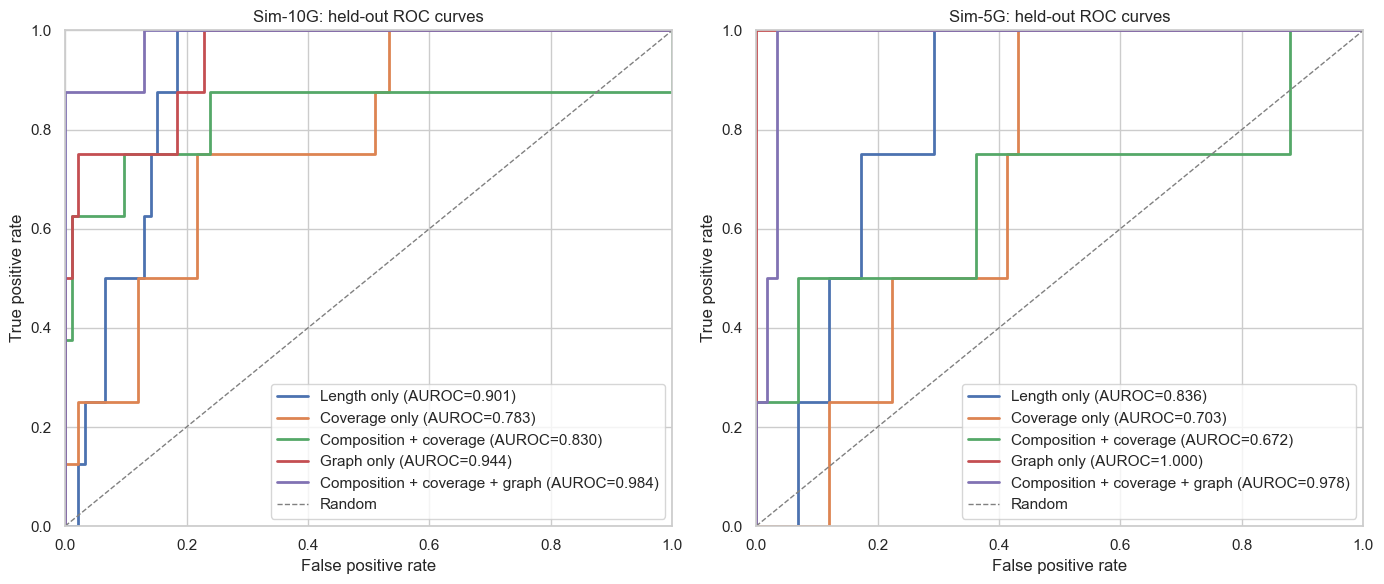

In [5]:
fig, axes = plt.subplots(1, len(comparison_results_by_dataset), figsize=(7 * len(comparison_results_by_dataset), 6))
if len(comparison_results_by_dataset) == 1:
    axes = [axes]

for ax, (dataset_name, results) in zip(axes, comparison_results_by_dataset.items()):
    plot_feature_set_roc_curves(results, ax=ax)
    ax.set_title(f"{dataset_name}: held-out ROC curves")

plt.tight_layout()
plt.show()

## Combined ROC Curves Across Datasets

These curves pool the held-out predictions from each dataset-specific run for the same feature set.

,feature_set_label,n_test,positive_rate,auroc,auprc
0,Length only,162,0.074,0.888,0.311
1,Coverage only,162,0.074,0.746,0.245
2,Composition + coverage,162,0.074,0.771,0.511
3,Graph only,162,0.074,0.966,0.815
4,Composition + coverage + graph,162,0.074,0.982,0.876


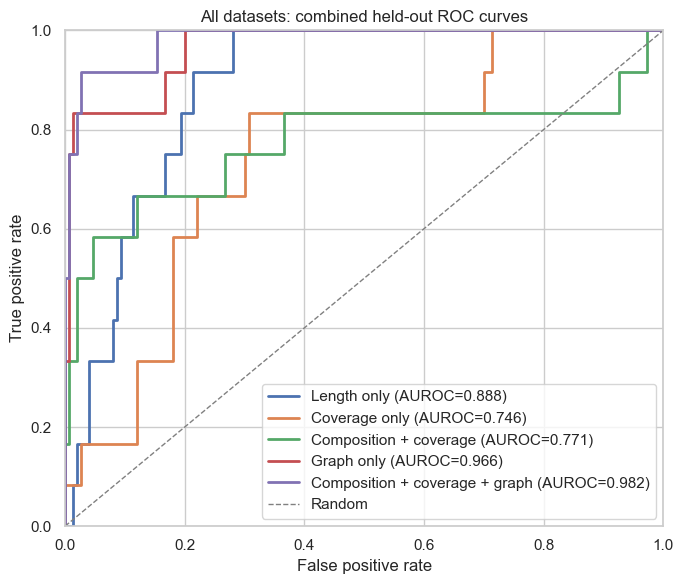

In [6]:
combined_table = combined_dataset_metric_table(
    comparison_results_by_dataset,
    feature_sets=COMPARISON_FEATURE_SETS,
)
display(
    combined_table[
        ["feature_set_label", "n_test", "positive_rate", "auroc", "auprc"]
    ].style.format({"positive_rate": "{:.3f}", "auroc": "{:.3f}", "auprc": "{:.3f}"})
)

fig, ax = plt.subplots(figsize=(7, 6))
plot_combined_dataset_roc_curves(
    comparison_results_by_dataset,
    feature_sets=COMPARISON_FEATURE_SETS,
    ax=ax,
)
ax.set_title("All datasets: combined held-out ROC curves")
plt.tight_layout()
plt.show()

## Full Feature-Set Importance

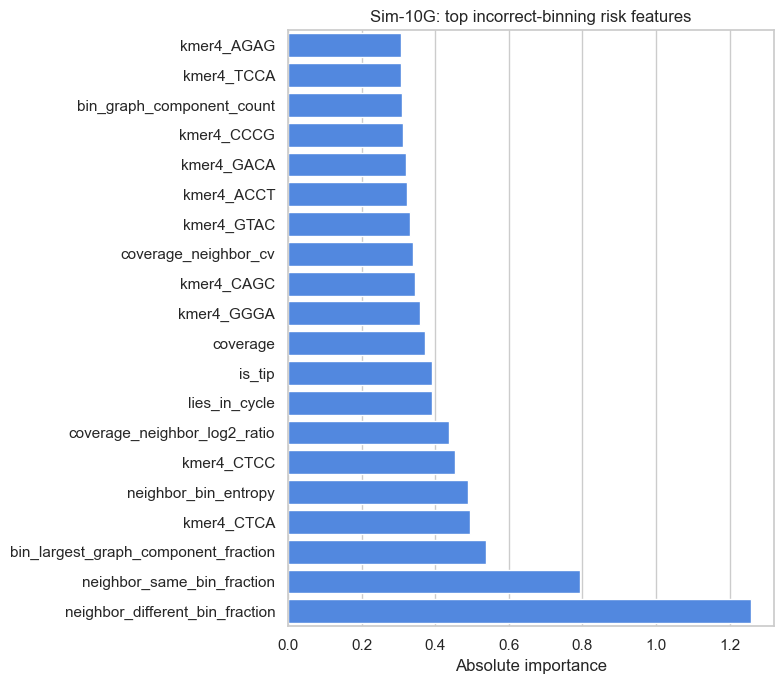

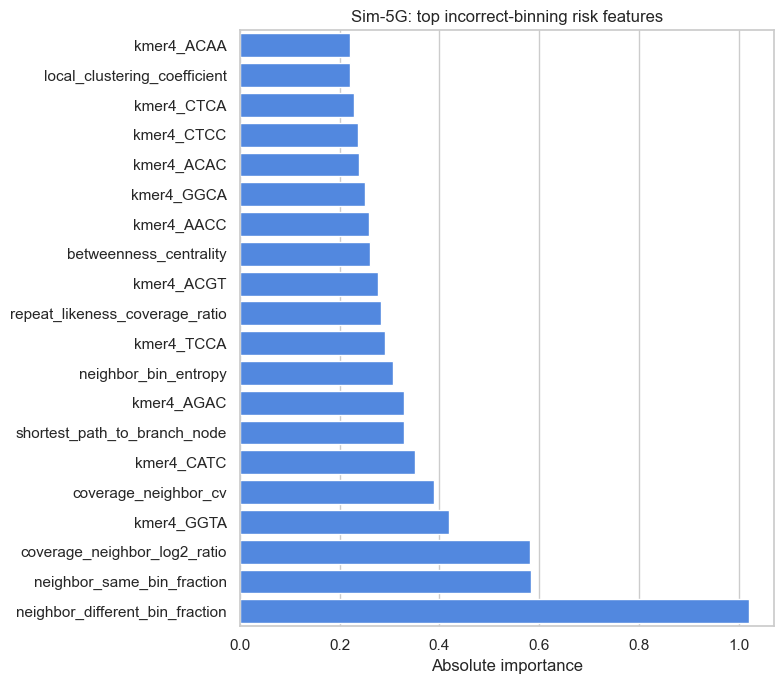

In [7]:
for dataset_name, results in comparison_results_by_dataset.items():
    top = results["composition_coverage_graph"].feature_importance.head(20).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 7))
    if sns is not None:
        sns.barplot(data=top, x="abs_importance", y="feature", ax=ax, color="#3b82f6")
    else:
        ax.barh(top["feature"], top["abs_importance"], color="#3b82f6")
    ax.set_xlabel("Absolute importance")
    ax.set_ylabel("")
    ax.set_title(f"{dataset_name}: top incorrect-binning risk features")
    plt.tight_layout()
    plt.show()

## SHAP Summary

Optional SHAP summary for the primary dataset using the composition + coverage + graph feature set.

/Users/vijinimallawaarachchi/miniforge3/envs/binfailgraph/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


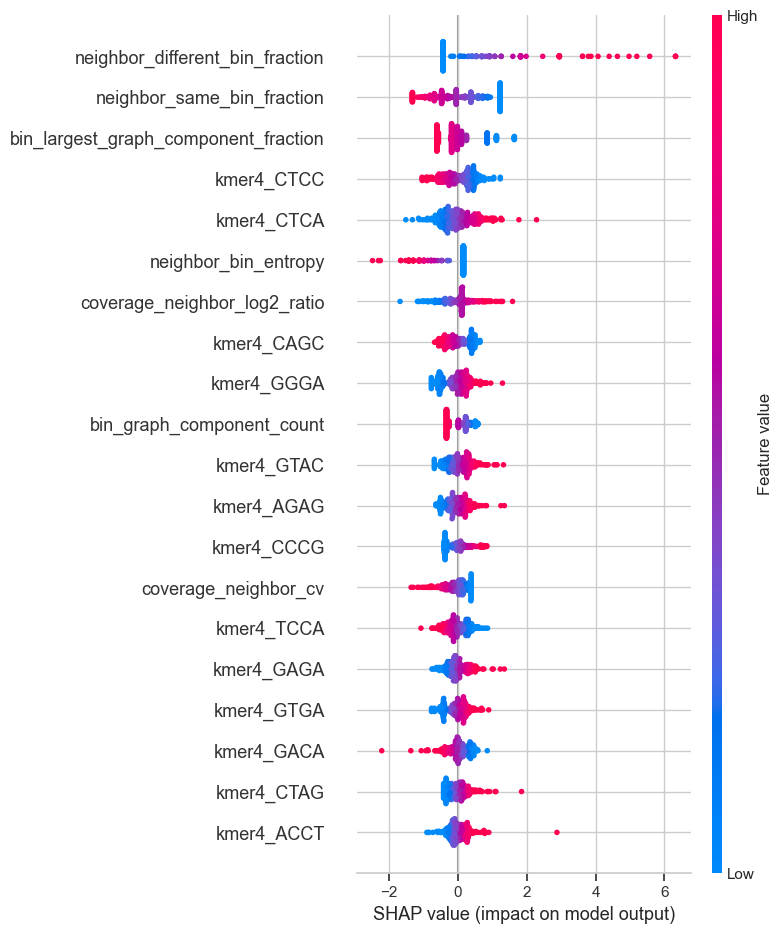

In [8]:
try:
    import shap

    transformed = result.model.named_steps["impute"].transform(primary_task[feature_columns])
    transformed = result.model.named_steps["scale"].transform(transformed)
    masker = shap.maskers.Independent(transformed, max_samples=min(100, transformed.shape[0]))
    explainer = shap.LinearExplainer(result.model.named_steps["model"], masker=masker)
    shap_values = explainer(transformed)
    shap.summary_plot(shap_values.values, transformed, feature_names=feature_columns, max_display=20)
except ImportError:
    print("Install shap from environment.yml to run this cell.")